# Neural Network

In [1]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

from utils import *
from logistic_regression import LogisticRegression

## Load Data

In [2]:
def load_data_npy():
    X = np.load("data/X.npy")
    y = np.load("data/y.npy")
    X = X[0:1000]
    y = y[0:1000]
    return X, y

def sigmoid(x):
    return 1. / (1. + np.exp(-x))

X, y = load_data_npy()

print ('The first element of y is: ', y[0,0])
print ('The last element of y is: ', y[-1,0])
print ('The shape of X is: ' + str(X.shape))
print ('The shape of y is: ' + str(y.shape))
# print ('The first element of X is: ', X[0])

The first element of y is:  0
The last element of y is:  1
The shape of X is: (1000, 400)
The shape of y is: (1000, 1)


## Visualizate the data

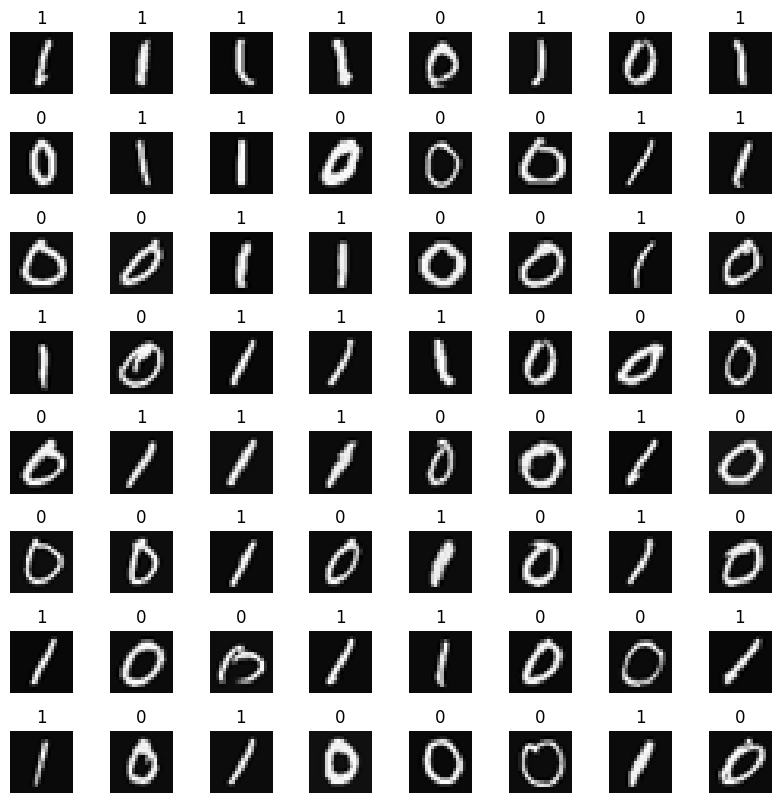

In [ ]:
m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1)

for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)
    
    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20))
    
    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Display the label above the image
    ax.set_title(y[random_index,0])
    ax.set_axis_off()

X shape: (1000, 400)
y shep: (1000, 1)
p_hat shape: (1000, 1)
[Layer  0] w shape: (400, 25), b shape: (25,)
[Layer  1] w shape: (25, 15), b shape: (15,)
[Layer  2] w shape: (15, 1), b shape: (1,)
Train Accuracy: 50.00%


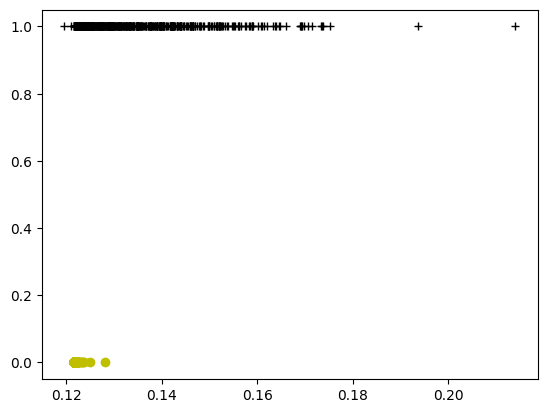

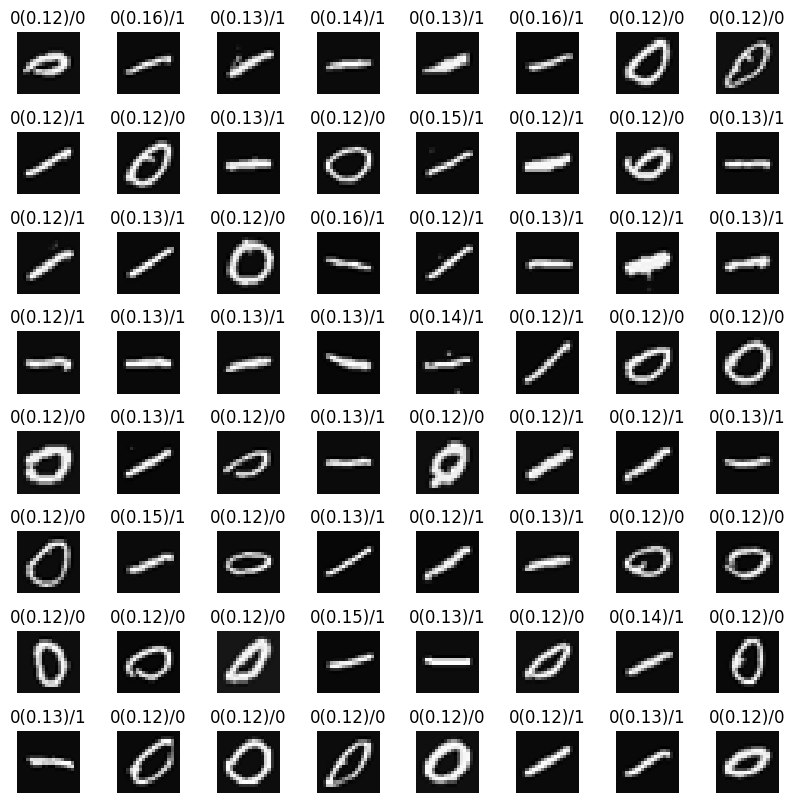

In [ ]:
from abc import abstractmethod
from typing import Tuple

class LossFunction:
    def __init__(self):
        pass

    def compute_cost(self, A, y) -> NDArray:
        pass

class ActivationFunction:
    def __init__(self):
        pass

    def compute_f(self, X, w, b) -> NDArray:
        z = np.dot(X, w) + b
        return self.activation(z)

    def forward(self, a: NDArray, w: NDArray, b: NDArray) -> NDArray:
        return self.compute_f(a, w, b)

    @abstractmethod
    def activation(self) -> NDArray:
        pass

    @abstractmethod
    def backward(self) -> NDArray:
        pass

class SigmoidActivation(ActivationFunction):

    def activation(self, z: NDArray) -> NDArray:
        g = 1 / (1 + np.exp(-z))
        return g

    def compute_dA(self, a: NDArray, y: NDArray) -> NDArray:
        dA = - (np.dividey(y, a) - np.divide(1 - y, 1 - a))
        return dA

    def backward(self, a: NDArray, y: NDArray, w: NDArray, b: NDArray) -> NDArray:
        dA = self.compute_dA(a, y)
        dA_dZ = a * (1 - a)
        dZ = dA * dA_dZ
        pass

class NeuralLayer:
    def __init__(self, units: int, activation: ActivationFunction, w_init: NDArray = None, b_init: NDArray = None):
        self.units = units
        self.activation = activation
        self.w = w_init
        self.b = b_init
    
    def init_weights(self, dim_in: int):
        self.w = 0.5 * (np.random.randn(dim_in, self.units) - 0.5)
        self.b = np.random.randn(self.units)
    
    def weights(self) -> Tuple[NDArray, NDArray]:
        return self.w, self.b

    def forward(self, a_in: NDArray) -> NDArray:
        m, n = a_in.shape
        if self.b is None or self.w is None:
            self.init_weights(n)
        a_out = self.activation.forward(a_in, self.w, self.b)
        return a_out

class NeuralNetwork:
    def __init__(self):
        self.layers = []
    
    def add_layer(self, layer: NeuralLayer):
        self.layers.append(layer)
    
    def weights(self) -> Tuple[NDArray, NDArray]:
        w = []
        b = []
        for layer in self.layers:
            w_layer, b_layer = layer.weights()
            w.append(w_layer)
            b.append(b_layer)
        return w, b
    
    def fit(self, X: NDArray, y: NDArray) -> NDArray:
        p_hat = self.predict(X)
        
        return p_hat

    def predict(self, X) -> NDArray:
        a = X
        for layer in self.layers:
            a = layer.forward(a)
        
        return a


def test_neural_network():
    x_tst = 0.1*np.arange(1,3,1).reshape(1,2)  # (1 examples, 2 features)
    W_tst = 0.1*np.arange(1,7,1).reshape(2,3) # (2 input features, 3 output features)
    b_tst = 0.1*np.arange(1,4,1).reshape(3,)  # (3 features)
    print(f'x_tst shape: {x_tst.shape}, W_tst shape: {W_tst.shape}, b_tst shape: {b_tst.shape}')
    nn_test = NeuralNetwork()
    layer = NeuralLayer(3, SigmoidActivation(), W_tst, b_tst)
    nn_test.add_layer(layer)
    print(nn_test.predict(x_tst))
        
nn = NeuralNetwork()
nn.add_layer(NeuralLayer(25, SigmoidActivation()))
nn.add_layer(NeuralLayer(15, SigmoidActivation()))
nn.add_layer(NeuralLayer(1, SigmoidActivation()))
def train():
    p_hat = nn.fit(X, y)
    print(f'X shape: {X.shape}')
    print(f'y shep: {y.shape}')
    print(f'p_hat shape: {p_hat.shape}')

    w_arr, b_arr = nn.weights()
    for i in range(len(w_arr)):
        print(f'[Layer {i:2d}] w shape: {w_arr[i].shape}, b shape: {b_arr[i].shape}')

    plot_data(p_hat, y[:,0], pos_label="y=1", neg_label="y=0")

def plot_data(X, y, pos_label="y=1", neg_label="y=0"):
    positive = y == 1
    negative = y == 0
    
    # Plot examples
    plt.plot(X[positive, 0], y[positive], 'k+', label=pos_label)
    plt.plot(X[negative, 0], y[negative], 'yo', label=neg_label)


def test_predict():
    p_hat = nn.predict(X).flatten()
    p = np.zeros(p_hat.shape[0])
    postive_idx = p_hat > 0.5
    p[postive_idx] = 1
    print(f'Train Accuracy: {np.mean(p == y) * 100:3.2f}%')

    m, n = X.shape
    fig, axes = plt.subplots(8,8, figsize=(8,8))
    fig.tight_layout(pad=0.1)
    for i,ax in enumerate(axes.flat):
        # Select random indices
        random_index = np.random.randint(m)
        
        # Select rows corresponding to the random indices and
        # reshape the image
        X_random_reshaped = X[random_index].reshape((20,20))
        
        # Display the image
        ax.imshow(X_random_reshaped, cmap='gray')
        
        # Display the label above the image
        ax.set_title(f'{int(p[random_index])}({p_hat[random_index]:.2f})/{y[random_index,0]}')
        ax.set_axis_off()

# test_neural_network()
train()
test_predict()
